In [1]:
import matplotlib.pyplot
import pandas
import tarfile

In [18]:
def parse_p99(file_path : str) -> pandas.Series:
    columns : list[str] = ['timestamp_ns', 'status', 'latency_ns']
    data_frames : list[pandas.DataFrame] = [
        pandas.read_csv(f"{file_path}/vegeta1.log", usecols=[0, 1, 2], header=None, names=columns),
        pandas.read_csv(f"{file_path}/vegeta2.log", usecols=[0, 1, 2], header=None, names=columns),
        pandas.read_csv(f"{file_path}/vegeta3.log", usecols=[0, 1, 2], header=None, names=columns),
    ]
    combined_data_frame : pandas.DataFrame = pandas.concat(data_frames, ignore_index=True)

    combined_data_frame['timestamp_ns'] = pandas.to_datetime(combined_data_frame['timestamp_ns'], unit='ns')
    combined_data_frame = combined_data_frame.set_index('timestamp_ns')

    #return combined_data_frame['latency_ns'].resample('1s').quantile(0.99).expanding().mean() / 1e6
    return combined_data_frame['latency_ns'].resample('1s').quantile(0.99) / 1e6
    
def plot_p99(file_path : str) -> None:
    latencies = parse_p99(file_path)

    matplotlib.pyplot.plot(latencies.to_numpy(), color="#1f78b4")
    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color='#a6cee3')
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color='#a6cee3')
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color='#a6cee3')
    matplotlib.pyplot.xlabel("Time (s)")
    matplotlib.pyplot.ylabel("P99 Latency (ms)")
    matplotlib.pyplot.legend()
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

/tmp/ipykernel_37224/1109107861.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplotlib.pyplot.legend()


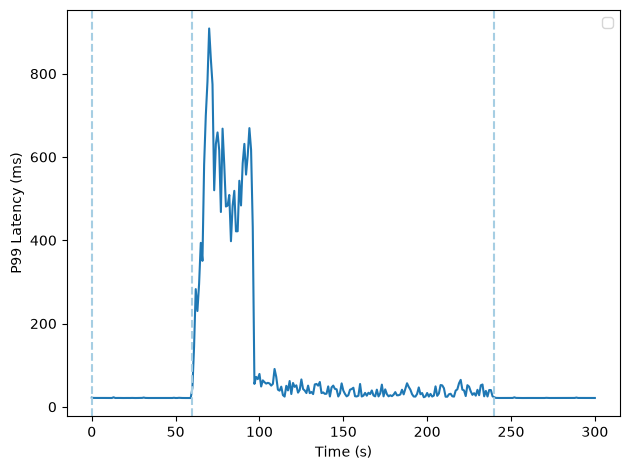

In [19]:
plot_p99(".");